# Demographic Bias in Open-Source Face-Recognition Embeddings

**Original exploratory notebook** (EAI6400 final project — Finn Pounds).
It streams a race-balanced FairFace subset, aligns faces with MTCNN, extracts
ArcFace and ViT embeddings, and measures how strongly race leaks into each.

> **Note:** the cleaned, reproducible, and *corrected* version of this workflow lives in
> [`../src/bias_pipeline.py`](../src/bias_pipeline.py). While refactoring, an input-normalization
> bug was found here: MTCNN's default `post_process=True` standardizes crops to ~[-1, 1], which the
> alignment cell below then rescales by `*255` and clamps — zeroing ~half of every crop before it
> reaches the models. The pipeline script fixes this (`post_process=False`); the figures and metrics
> in the README come from that corrected run. This notebook is kept as the historical record.

In [1]:
# 0: Imports and Setup

# ── Standard library ──────────────────────────────────────────────────────────
from pathlib import Path
import json
import random
import re       
# ── Third-party core ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm                            # unified tqdm import

# ── Vision & model hubs ──────────────────────────────────────────────────────
from datasets import load_dataset
from facenet_pytorch import MTCNN
from transformers import AutoImageProcessor, AutoModel
import insightface
from insightface.model_zoo import get_model

# ── ML / stats ───────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    r2_score,
    silhouette_score,
    pairwise_distances,      # if silhouette_score on pre-computed distances
)
from sklearn.metrics.pairwise import cosine_similarity

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

CACHE_FILE  = Path("embed_cache.npz")    # reuse between runs

/Users/finnpounds/biasface/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1: Download and save balanced FairFace Subset 

# Resolve the dataset folder relative to the repo, wherever the notebook is launched from.
_here = Path.cwd()
DATA_ROOT = next((p / "fairface_subset" for p in [_here, *_here.parents]
                  if (p / "fairface_subset").exists()), _here / "fairface_subset")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

N_PER_RACE = 1000
def canon(r):           # replace underscores → spaces
    return r.replace("_", " ")

counter = {}            # fill dynamically

ds = load_dataset("HuggingFaceM4/FairFace", "0.25",
                  split="train", streaming=True, cache_dir=".hf_cache")
to_str = ds.features["race"].int2str

for ex in tqdm(ds, desc="Streaming FairFace"):
    race_raw = to_str(ex["race"])        # e.g. "Latino Hispanic"
    race     = canon(race_raw)
    counter.setdefault(race, 0)
    if counter[race] >= N_PER_RACE:
        if all(v >= N_PER_RACE for v in counter.values()):
            break
        continue

    pil: Image = ex["image"].convert("RGB")
    fname = f"{race.replace(' ', '_')}_{counter[race]:04d}.jpg"
    pil.save(DATA_ROOT / fname, quality=95)
    counter[race] += 1

print("Saved", sum(counter.values()), "images →", DATA_ROOT)
print(counter)

Streaming FairFace: 9550it [00:06, 1435.10it/s]

Saved 7000 images → /Users/finnpounds/biasface/fairface_subset
{'East Asian': 1000, 'Indian': 1000, 'Black': 1000, 'White': 1000, 'Middle Eastern': 1000, 'Latino Hispanic': 1000, 'Southeast Asian': 1000}


In [3]:
# 2: Build df_sampled
try:
    DATA_ROOT
except NameError:
    raise RuntimeError("DATA_ROOT missing – run the download cell or set it manually.")

IMG_DIR = DATA_ROOT
jpg_paths = sorted(IMG_DIR.glob("*.jpg"))
if not jpg_paths:
    raise FileNotFoundError(f"No *.jpg images found in {IMG_DIR}. Did the download step succeed?")

def race_from_fname(fname: str) -> str:
    m = re.match(r"(.+)_\d+\.jpg$", fname)
    if not m:
        raise ValueError(f"Unexpected filename pattern: {fname!r}")
    return m.group(1).replace("_", " ")     # "Latino_Hispanic" → "Latino Hispanic"

df_sampled = pd.DataFrame({
    "path":  [str(p) for p in jpg_paths],
    "race":  [race_from_fname(p.name) for p in jpg_paths],
})
race_names = {r: i for i, r in enumerate(sorted(df_sampled["race"].unique()))}

print(f"df_sampled rows: {len(df_sampled)}")
print("Races → idx:", race_names)

df_sampled rows: 7000
Races → idx: {'Black': 0, 'East Asian': 1, 'Indian': 2, 'Latino Hispanic': 3, 'Middle Eastern': 4, 'Southeast Asian': 5, 'White': 6}


In [4]:
# 3: MTCNN alignment
mtcnn = MTCNN(
    image_size=112, margin=0,
    thresholds=[0.6,0.7,0.7],
    keep_all=False, device=device
)

# pick the right enum for your Pillow version
try:
    RESAMPLE_BICUBIC = Image.Resampling.BICUBIC   # Pillow ≥ 10
except AttributeError:
    RESAMPLE_BICUBIC = Image.BICUBIC              # Pillow < 10

def upscale_if_needed(pil_img, target=256):
    w, h = pil_img.size
    if min(w, h) < target:
        scale = target / min(w, h)
        new_wh = (round(w * scale), round(h * scale))
        pil_img = pil_img.resize(new_wh, RESAMPLE_BICUBIC)
    return pil_img


def align_face(pil_img):
    pil_img = upscale_if_needed(pil_img)
    crop = mtcnn(pil_img)                      # C×H×W, 0-1
    if crop is None:
        return None
    crop = (crop.permute(1,2,0)*255).clamp(0,255)  # H×W×C, float32 0-255
    return crop.cpu().numpy().astype("float32")

aligned = []
labels  = []

for row in tqdm(df_sampled.itertuples(), total=len(df_sampled), desc="align"):
    img  = Image.open(row.path).convert("RGB")   # ← load JPEG on-demand
    crop = align_face(img)
    if crop is not None:
        aligned.append(crop)
        labels.append(race_names[row.race])

print("Aligned faces:", len(aligned))

align: 100%|████████████████████████████████| 7000/7000 [01:23<00:00, 84.07it/s]

Aligned faces: 6821


In [5]:
# 4: REBUILD meta_df (metadata table)
# Resolve the dataset folder relative to the repo, wherever the notebook is launched from.
_here = Path.cwd()
DATA_ROOT = next((p / "fairface_subset" for p in [_here, *_here.parents]
                  if (p / "fairface_subset").exists()), _here / "fairface_subset")
IMG_EXTS  = {".jpg", ".jpeg", ".png", ".JPG"}

imgs = [p for p in DATA_ROOT.rglob("*") if p.suffix in IMG_EXTS]
assert imgs, f"No images found in {DATA_ROOT}"

records = []
for p in imgs:
    # keep text before last underscore as race token
    m = re.match(r"(.+)_\d+$", p.stem)
    race_token = m.group(1) if m else p.stem
    race = race_token.replace("_", " ")
    records.append({"path": str(p), "race": race})

meta_df = pd.DataFrame.from_records(records)
print("meta_df built with", len(meta_df), "rows")
print(meta_df.groupby("race").size())

meta_df built with 7000 rows
race
Black              1000
East Asian         1000
Indian             1000
Latino Hispanic    1000
Middle Eastern     1000
Southeast Asian    1000
White              1000
dtype: int64


In [6]:
# 5: ArcFace (buffalo_l) + ViT loaders & helpers

# 1. ArcFace recogniser (buffalo_l is always shipped with InsightFace)
arc = get_model(
    name="buffalo_l",
    root="~/.insightface",
    providers=["CPUExecutionProvider"],
)                     

@torch.inference_mode()
def emb_arc(np_img):
    """RGB numpy → (512,) torch; raw length recreated with scale*64."""
    bgr  = np_img[:, :, ::-1].astype("uint8")     # RGB→BGR
    vec  = arc.get_feat(bgr).squeeze()            # unit-norm
    return torch.from_numpy(vec).float()

# 2. ViT-Base (unchanged)
vit_proc = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k", use_fast = "TRUE") # Optional: remove use_fast = "TRUE"
vit      = AutoModel.from_pretrained("google/vit-base-patch16-224-in21k").to(device).eval()

@torch.inference_mode()
def emb_vit(np_img):
    pil = Image.fromarray(np_img.astype("uint8"), mode="RGB")
    cls = vit(**vit_proc(images=pil, return_tensors="pt").to(device)
             ).last_hidden_state[:, 0, :]
    return cls.squeeze(0).cpu()


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


In [7]:
# 6: Extract embeddings 
arc_raw = torch.stack([emb_arc(img) for img in tqdm(aligned, desc="Arc")])
vit_raw = torch.stack([emb_vit(img) for img in tqdm(aligned, desc="ViT")])
labels  = list(labels)     # ensure plain Python list

print("arc_raw:", arc_raw.shape, "vit_raw:", vit_raw.shape)  # (N,512) (N,768)

arc_unit = arc_raw                                  # (N,512) unit-norm
vit_unit = vit_raw / vit_raw.norm(dim=1, keepdim=True) #norm the ViT Embeddings

ViT: 100%|██████████████████████████████████| 6821/6821 [06:01<00:00, 18.88it/s]


arc_raw: torch.Size([6821, 512]) vit_raw: torch.Size([6821, 768])


/Users/finnpounds/biasface/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/finnpounds/biasface/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


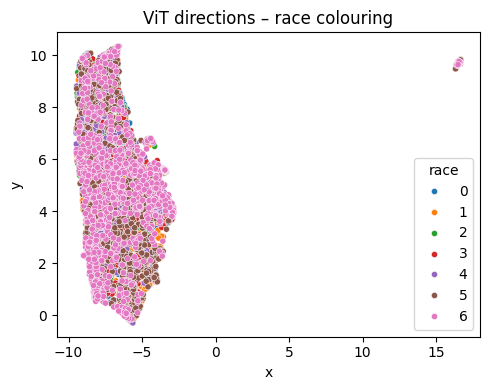

/Users/finnpounds/biasface/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/finnpounds/biasface/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


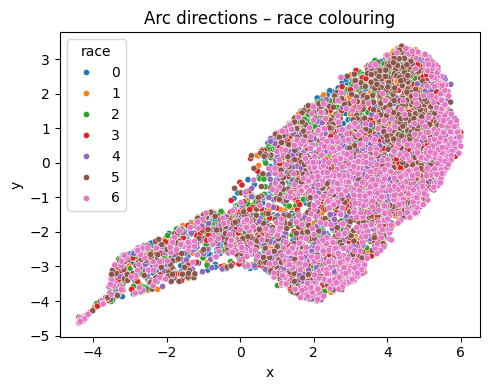

In [8]:
# 7: UMAP visual for both ViT and Arc embeddings

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

def plot_umap(emb_tensor, y, title,
              n_neighbors=15, min_dist=0.1,
              metric="cosine", random_state=42):
    """
    Draw a 2-D UMAP scatter coloured by race.

    Parameters
    ----------
    emb_tensor : torch.Tensor  (N, D)  Unit-norm embeddings.
    y          : list / array  Length-N race labels (ints or strings).
    title      : str          Plot title.
    n_neighbors, min_dist, metric, random_state : UMAP hyper-params.
    """
    xy = UMAP(n_neighbors=n_neighbors,
              min_dist=min_dist,
              metric=metric,
              random_state=random_state
             ).fit_transform(emb_tensor.numpy())

    df = pd.DataFrame(dict(x=xy[:, 0], y=xy[:, 1], race=y))

    plt.figure(figsize=(5, 4))
    sns.scatterplot(data=df, x="x", y="y",
                    hue="race", palette="tab10", s=20)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# --- call once for each embedding set ---------------------------------------
plot_umap(vit_unit, labels, "ViT directions – race colouring")
plot_umap(arc_unit, labels, "Arc directions – race colouring")


In [9]:
# 8: Setup and Labels

canon = lambda r: r.replace("_", " ")

inv_race_names = {v: k for k, v in race_names.items()}   # int → str

races_full    = [canon(r) for r in meta_df["race"].values]          # attempted
races_aligned = np.asarray([canon(inv_race_names[i]) for i in labels])  # succeeded

arc_np = arc_unit.cpu().numpy() if isinstance(arc_unit, torch.Tensor) else arc_unit
vit_np = vit_unit.cpu().numpy() if isinstance(vit_unit, torch.Tensor) else vit_unit

In [10]:
# 9: directional-leakage metrics 
def cosine_gap(X, y):
    sims = cosine_similarity(X)
    y = np.asarray(y)
    return float(sims[y[:, None] == y].mean() - sims[y[:, None] != y].mean())

def knn_acc(X, y, k=5):
    return float(KNeighborsClassifier(k, metric="cosine").fit(X, y).score(X, y))

def probe_auc(X, y):
    y_codes = pd.Categorical(y).codes
    aucs = []
    for r in np.unique(y_codes):
        y_bin = (y_codes == r).astype(int)
        clf = LogisticRegression(max_iter=500, n_jobs=-1, solver="lbfgs").fit(X, y_bin)
        aucs.append(roc_auc_score(y_bin, clf.predict_proba(X)[:, 1]))
    return float(np.mean(aucs))

dir_leak = {
    "arc": {"cosine_gap": cosine_gap(arc_np, races_aligned),
            "knn5":       knn_acc  (arc_np, races_aligned),
            "auc":        probe_auc(arc_np, races_aligned)},
    "vit": {"cosine_gap": cosine_gap(vit_np, races_aligned),
            "knn5":       knn_acc  (vit_np, races_aligned),
            "auc":        probe_auc(vit_np, races_aligned)}
}

In [11]:
# 10: Distance stats
def race_similarity_stats(X, y):
    sims = cosine_similarity(X)
    races = np.unique(y)
    stats = {"within": {}, "between": {}}
    for r in races:
        idx = np.where(y == r)[0]
        if len(idx) > 1:
            sims_w = sims[np.ix_(idx, idx)]
            stats["within"][r] = float(sims_w[np.triu_indices(len(idx), 1)].mean())
    for i, r1 in enumerate(races):
        for r2 in races[i + 1:]:
            idx1, idx2 = np.where(y == r1)[0], np.where(y == r2)[0]
            stats["between"][f"{r1}–{r2}"] = float(sims[np.ix_(idx1, idx2)].mean())
    return stats

dist_stats_arc = race_similarity_stats(arc_np, races_aligned)
dist_stats_vit = race_similarity_stats(vit_np, races_aligned)

In [12]:
# 11: detector / alignment fairness
attempt_counts = pd.Series(races_full).value_counts()
keep_counts    = pd.Series(races_aligned).value_counts()
keep_rate      = (keep_counts / attempt_counts).fillna(0).to_dict()

In [13]:
# 12: consolidate & show 
fair_report = {
    "directional_leakage": dir_leak,
    "distance_stats":      {"arc": dist_stats_arc, "vit": dist_stats_vit},
    "detector_alignment":  {"keep_rate": keep_rate}
}

data = fair_report

# a) Directional-leakage summary table
dl = data["directional_leakage"]
df_leak = (pd.DataFrame(dl).T
           .rename_axis("model")
           .reset_index()
           .round(3))
print("\nDirectional leakage")
display(df_leak)

# b) Keep-rate table
keep = pd.Series(data["detector_alignment"]["keep_rate"]).rename("keep_rate")
print("\nDetector / alignment keep-rate")
display(keep.to_frame().round(3))

# c) Within-race distance (Arc vs ViT) side-by-side
d_arc = pd.Series(data["distance_stats"]["arc"]["within"], name="arc_within")
d_vit = pd.Series(data["distance_stats"]["vit"]["within"], name="vit_within")
df_within = pd.concat([d_arc, d_vit], axis=1).round(3)
print("\nWithin-race cosine similarity (1 = identical)")
display(df_within)


Directional leakage


,model,cosine_gap,knn5,auc
0,arc,0.011,0.517,0.842
1,vit,0.018,0.530,0.831



Detector / alignment keep-rate


,keep_rate
Black,0.967
East Asian,0.974
Indian,0.981
Latino Hispanic,0.984
Middle Eastern,0.965
Southeast Asian,0.980
White,0.970



Within-race cosine similarity (1 = identical)


,arc_within,vit_within
Black,0.320,0.278
East Asian,0.176,0.288
Indian,0.240,0.298
Latino Hispanic,0.196,0.299
Middle Eastern,0.210,0.280
Southeast Asian,0.208,0.289
White,0.171,0.268


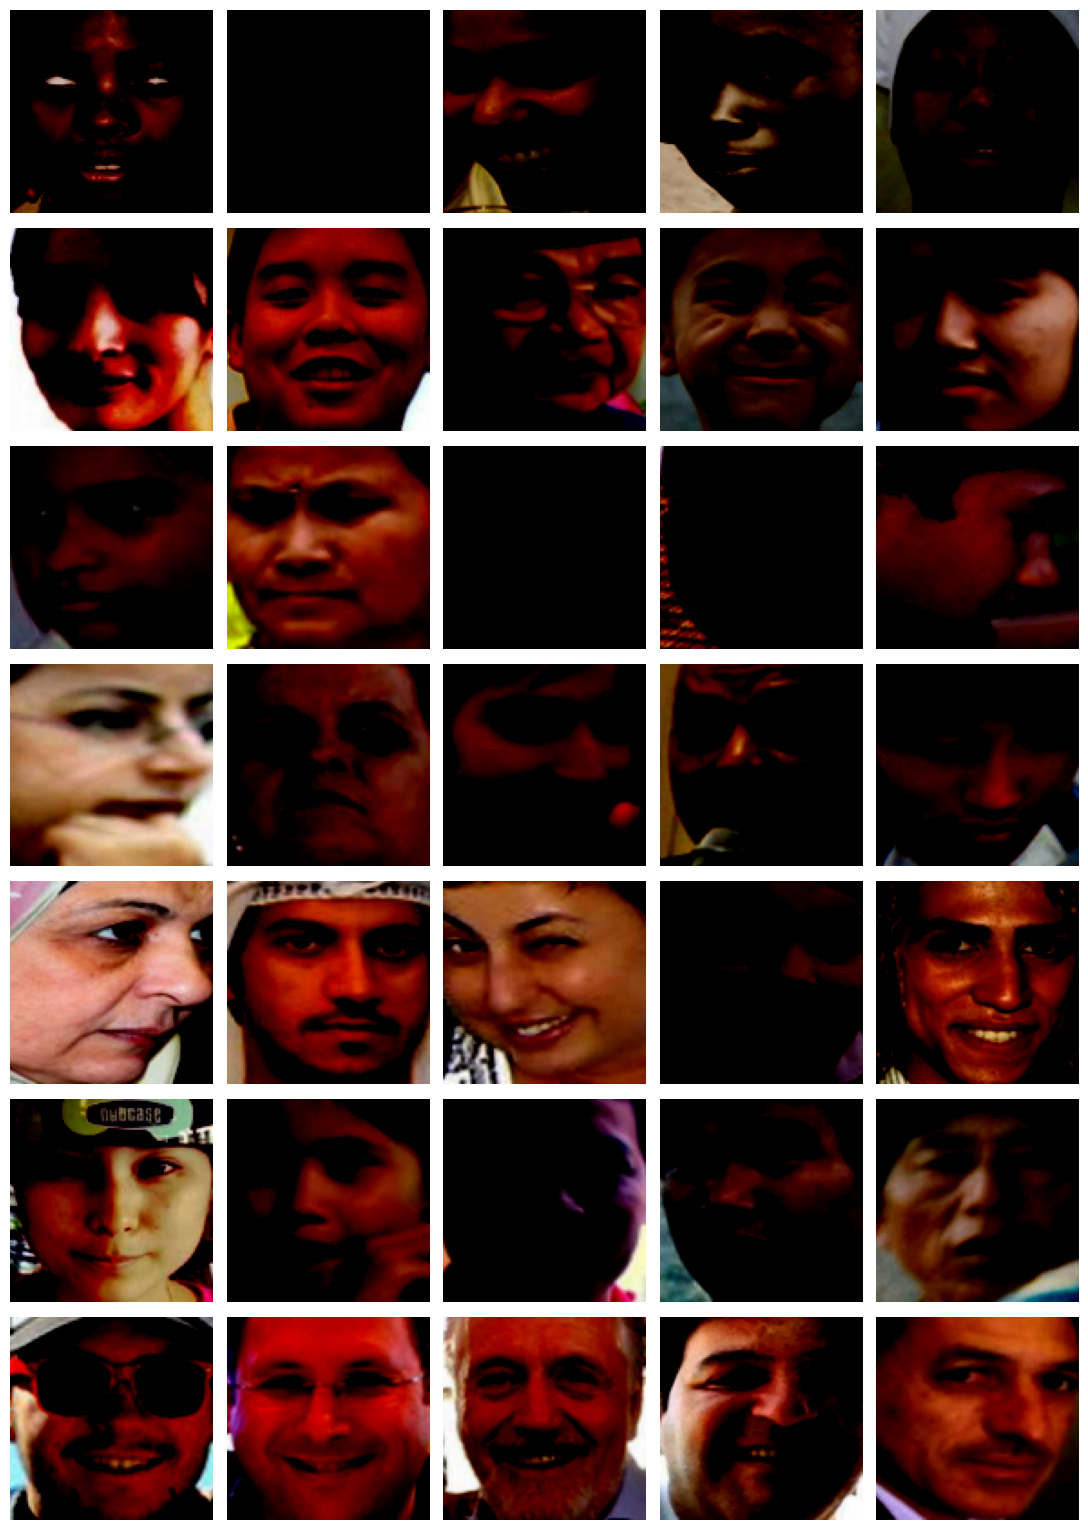

In [14]:
# 13: Display 5 random samples per race  -----------------------------------

imgs   = aligned               # list/array of H×W×3 float32 (0-255)
races  = np.asarray(labels)
uniq   = sorted(set(races))
K      = 5                     # thumbnails per race

fig, axs = plt.subplots(len(uniq), K, figsize=(K*2.2, len(uniq)*2.2))
for r_idx, race in enumerate(uniq):
    idxs = np.where(races == race)[0]
    choose = random.sample(list(idxs), min(K, len(idxs)))
    for c_idx, i in enumerate(choose):
        ax = axs[r_idx, c_idx] if len(uniq) > 1 else axs[c_idx]
        ax.imshow(imgs[i].astype("uint8"))
        ax.axis("off")
        if c_idx == 0:
            ax.set_ylabel(race, fontsize=12, rotation=0, labelpad=40, va="center")
plt.tight_layout(); plt.show()

In [15]:
# 14: One-vs-rest logistic probe • stratified train/test split

def ovsr_auc_split(X, y, test_size=0.30, random_state=42,
                   cv_folds=5, solver="lbfgs"):
    """
    Train once on (70%) and evaluate on held-out (30%) for every race label.
    Returns a Series with per-race AUC and the macro mean.
    """
    races = np.unique(y)
    scores = {}
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state)

    for r in races:
        y_tr_bin = (y_tr == r).astype(int)
        y_te_bin = (y_te == r).astype(int)

        clf = make_pipeline(
            StandardScaler(with_mean=False),
            LogisticRegressionCV(
                Cs=10, cv=cv_folds,
                penalty="l2", solver=solver,
                max_iter=5000, n_jobs=-1)
        ).fit(X_tr, y_tr_bin)

        scores[r] = roc_auc_score(y_te_bin, clf.predict_proba(X_te)[:, 1])

    scores["macro_avg"] = np.mean(list(scores.values()))
    return pd.Series(scores).round(3)

# ---------- run probe on both embeddings ----------
vit_split_auc = ovsr_auc_split(vit_unit.numpy(), np.array(labels))
arc_split_auc = ovsr_auc_split(arc_unit.numpy(), np.array(labels))

display(pd.DataFrame({
    "ViT AUC":  vit_split_auc,
    "Arc AUC":  arc_split_auc
}))


,ViT AUC,Arc AUC
0,0.862,0.832
1,0.816,0.808
2,0.754,0.730
3,0.661,0.637
4,0.755,0.714
5,0.719,0.744
6,0.817,0.773
macro_avg,0.769,0.748
